In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from scipy.stats import randint
from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.ensemble import StackingClassifier

import joblib

In [5]:
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

In [7]:
from sklearn.ensemble import VotingClassifier

# step 1 — define base classifiers with best params
clf1 = LogisticRegression(C=0.59, solver='saga', max_iter=1000, random_state=42)
clf2 = GradientBoostingClassifier(learning_rate=0.017, max_depth=4, n_estimators=108, subsample=0.76, random_state=42)
clf3 = SVC(probability=True, kernel='linear', gamma='auto', C=0.22, random_state=42)

# step 2 — voting classifier
voting_clf = VotingClassifier(
    estimators=[('lr', clf1), ('gb', clf2), ('svm', clf3)],
    voting='soft'
)

# step 3 — wrap in pipeline
voting_pipeline = Pipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  voting_clf)
])

# step 4 — cross validate FIRST
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    voting_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=['f1', 'roc_auc'],
    return_train_score=False
)

print(f"Voting F1:      {scores['test_f1'].mean():.3f}")
print(f"Voting ROC-AUC: {scores['test_roc_auc'].mean():.3f}")

Voting F1:      0.828
Voting ROC-AUC: 0.882


In [10]:
from sklearn.ensemble import StackingClassifier
clf1 = LogisticRegression(C=0.59, solver='saga', max_iter=1000, random_state=42)
clf2 = GradientBoostingClassifier(learning_rate=0.017, max_depth=4, n_estimators=108, subsample=0.76, random_state=42)
clf3 = SVC(probability=True, kernel='linear', gamma='auto', C=0.22, random_state=42)
Meta_learner = LogisticRegression(max_iter=1000)
Stacking_clf=StackingClassifier(
    estimators =[('lr', clf1), ('gb', clf2), ('svm', clf3)],
    final_estimator=Meta_learner
)
stacking_pipeline = Pipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  Stacking_clf)
])
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_validate(
    stacking_pipeline,
    X_train, y_train,
    cv=cv,
    scoring=['f1', 'roc_auc'],
    return_train_score=False
)
print(f"stacking F1:      {scores['test_f1'].mean():.3f}")
print(f"stacking ROC-AUC: {scores['test_roc_auc'].mean():.3f}")

stacking F1:      0.823
stacking ROC-AUC: 0.881


In [13]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators':  trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth':     trial.suggest_int('max_depth', 2, 8),
        'subsample':     trial.suggest_float('subsample', 0.6, 1.0)
    }

    pipeline = Pipeline([
        ('smote',  SMOTE(random_state=42)),
        ('scaler', StandardScaler()),
        ('model',  GradientBoostingClassifier(**params, random_state=42))
    ])

    scores = cross_validate(
        pipeline,
        X_train, y_train,
        cv=cv,
        scoring='f1',
        return_train_score=False
    )

    return scores['test_score'].mean()


study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Best Params:", study.best_params)
print("Best F1:",     round(study.best_value, 3))

Best Params: {'n_estimators': 290, 'learning_rate': 0.02791259477382097, 'max_depth': 3, 'subsample': 0.7217119503664859}
Best F1: 0.83


              precision    recall  f1-score   support

           0       0.85      0.76      0.80        82
           1       0.82      0.89      0.85       102

    accuracy                           0.83       184
   macro avg       0.83      0.82      0.83       184
weighted avg       0.83      0.83      0.83       184

ROC-AUC: 0.913


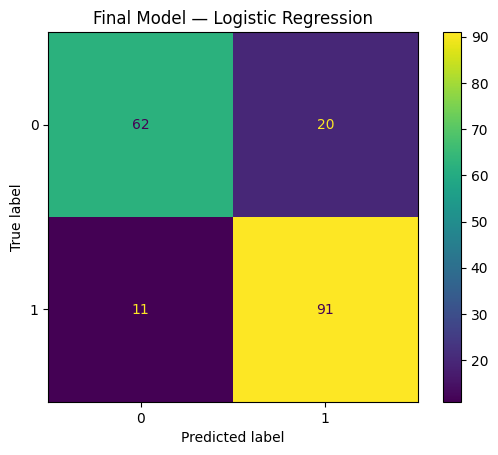

In [14]:
import joblib

best_model = joblib.load('../models/lr_best_model.pkl')
y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(f'ROC-AUC: {roc_auc_score(y_test, y_prob):.3f}')

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title('Final Model — Logistic Regression')
plt.show()

In [15]:
gb_optuna = Pipeline([
    ('smote',  SMOTE(random_state=42)),
    ('scaler', StandardScaler()),
    ('model',  GradientBoostingClassifier(
        n_estimators=290,
        learning_rate=0.028,
        max_depth=3,
        subsample=0.72,
        random_state=42
    ))
])

gb_optuna.fit(X_train, y_train)
joblib.dump(gb_optuna, '../models/gb_optuna_model.pkl')
print("saved")

saved
